First, let's explore our data

In [1]:
import pandas as pd

df = pd.read_csv('customer.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print(df.sample(10))

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
5876  4844-JJWUY  Female              1      No         No       1   
6470  4544-RXFMG    Male              0     Yes        Yes       8   
1774  5207-PLSTK    Male              0     Yes        Yes       1   
2761  2408-WITXK  Female              1      No         No      10   
4952  7379-FNIUJ    Male              0      No         No       2   
1586  3766-EJLFL  Female              0     Yes        Yes      68   
1246  9408-HRXRK  Female              0     Yes        Yes      45   
3848  8805-JNRAZ  Female              0      No         No       2   
1575  2003-CKLOR    Male              0      No         No      66   
6219  1496-GGSUK  Female              1      No         No       1   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
5876          Yes                No     Fiber optic             No  ...   
6470          Yes                No             DSL             No  ...   
1774

Let's do data Preprocessing

First we will remove customerID column because it has no use in predicting churn.

In [6]:
df = df.drop('customerID', axis=1)
print(df.shape)

(7043, 20)


Now, let's convert totalcharges column fro str to numeric.

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print(df['TotalCharges'].dtype)

float64


In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

As, we can see only 11 vales are missing so if we can drop them then nothing will change in dataset. So, let's drop it.

In [9]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 20)


In [10]:
print(df['Churn'].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


As, we can see data is imbalanced. We, wil fix it later. First, we will convert our yes/no into 1/0. 

In [11]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [12]:
df['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [13]:
print(df.select_dtypes(include='object').columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


C:\Users\upadh\AppData\Local\Temp\ipykernel_31920\2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [14]:
df['Dependents']

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041     No
7042     No
Name: Dependents, Length: 7032, dtype: str

In [15]:
df['PhoneService']

0        No
1       Yes
2       Yes
3        No
4       Yes
       ... 
7038    Yes
7039    Yes
7040     No
7041    Yes
7042    Yes
Name: PhoneService, Length: 7032, dtype: str

In [16]:
df['OnlineSecurity']

0        No
1       Yes
2       Yes
3       Yes
4        No
       ... 
7038    Yes
7039     No
7040    Yes
7041     No
7042    Yes
Name: OnlineSecurity, Length: 7032, dtype: str

In [17]:
yes_no_cols1 = ['Partner', 'Dependents', 'PhoneService',
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'PaperlessBilling']

for col in yes_no_cols1:
    df[col] = df[col].map({'Yes':1, 'No':0, 'No internet service': 0,
                           'No phone service': 0})

print(df.isnull().sum().sum())

0


In [18]:
df['DeviceProtection']

0       0
1       1
2       0
3       1
4       0
       ..
7038    1
7039    1
7040    0
7041    0
7042    1
Name: DeviceProtection, Length: 7032, dtype: int64

In [19]:
df['MultipleLines']

0       No phone service
1                     No
2                     No
3       No phone service
4                     No
              ...       
7038                 Yes
7039                 Yes
7040    No phone service
7041                 Yes
7042                  No
Name: MultipleLines, Length: 7032, dtype: str

We ahve converted simple columns having only yes/no values to numeric using simple code but for text containing columns we have to use one hot encoding

In [20]:
print(df.select_dtypes(include='object').columns)

Index(['gender', 'MultipleLines', 'InternetService', 'Contract',
       'PaymentMethod'],
      dtype='str')


C:\Users\upadh\AppData\Local\Temp\ipykernel_31920\2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [21]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [22]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [23]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [24]:
df = pd.get_dummies(df, columns=['gender', 'MultipleLines', 'InternetService', 'Contract', 
                                  'PaymentMethod'], drop_first=True)
print(df.shape)

(7032, 25)


In [25]:
df['gender_Male']

0       False
1        True
2        True
3        True
4       False
        ...  
7038     True
7039    False
7040    False
7041     True
7042     True
Name: gender_Male, Length: 7032, dtype: bool

In [26]:
print(df.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Male',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [27]:
df['gender_Male']

0       False
1        True
2        True
3        True
4       False
        ...  
7038     True
7039    False
7040    False
7041     True
7042     True
Name: gender_Male, Length: 7032, dtype: bool

In [28]:
print(df.select_dtypes(include='bool').columns)

Index(['gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')


In [29]:
yes_no_cols2 = df.select_dtypes(include='bool').columns
df[yes_no_cols2] = df[yes_no_cols2].astype(int)

print(df.shape)
print(df.isnull().sum().sum())

(7032, 25)
0


In [30]:
df['gender_Male']

0       0
1       1
2       1
3       1
4       0
       ..
7038    1
7039    0
7040    0
7041    1
7042    1
Name: gender_Male, Length: 7032, dtype: int64

In [31]:
df['MultipleLines_Yes']

0       0
1       0
2       0
3       0
4       0
       ..
7038    1
7039    1
7040    0
7041    1
7042    0
Name: MultipleLines_Yes, Length: 7032, dtype: int64

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

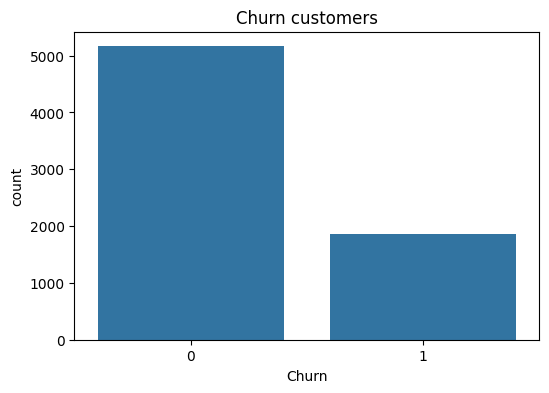

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn customers')
plt.show()

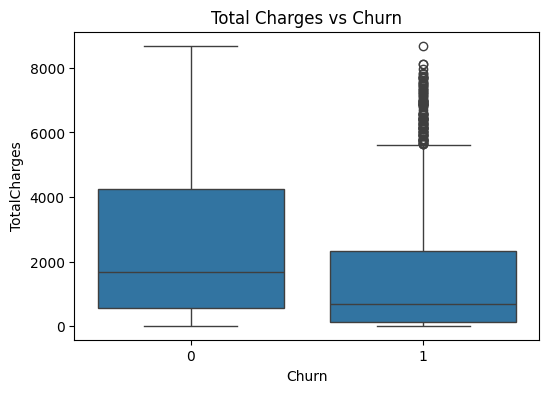

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('Total Charges vs Churn')
plt.show()

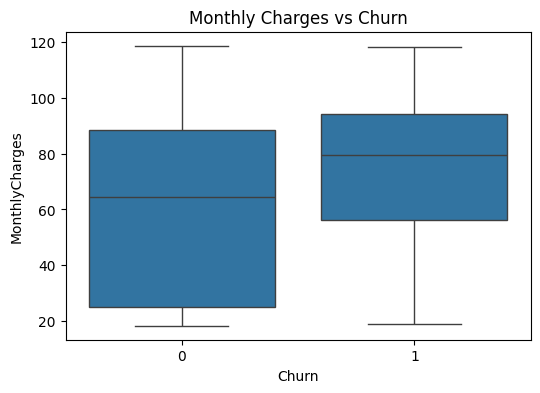

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x = 'Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

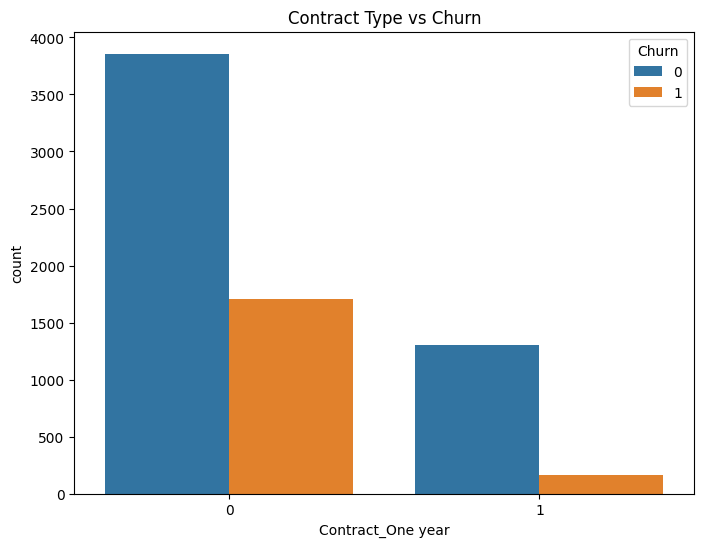

In [36]:
plt.figure(figsize=(8,6))
sns.countplot(x='Contract_One year',hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

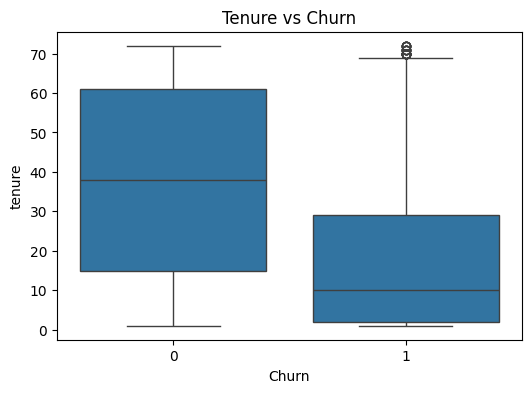

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

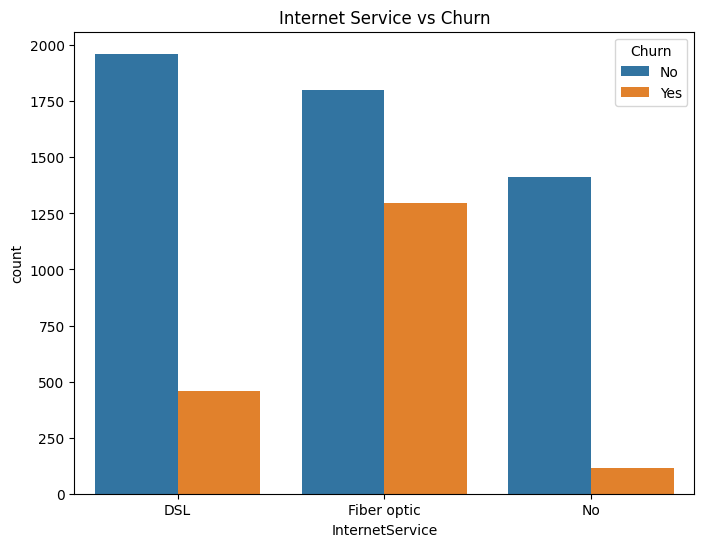

In [38]:
df2 = pd.read_csv("customer.csv")
plt.figure(figsize=(8,6))
sns.countplot(x='InternetService', hue='Churn', data=df2)
plt.title('Internet Service vs Churn')
plt.show()

In [39]:
df2.groupby('InternetService')['MonthlyCharges'].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

In [40]:
df.shape

(7032, 25)

In [41]:
X= df.drop("Churn", axis=1)
y= df['Churn']

In [42]:
df.shape

(7032, 25)

In [43]:
print(X.shape)

(7032, 24)


In [44]:
print(y.shape)

(7032,)


In [45]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(X_train.isnull().sum().sum())
print(X_train.shape)
print(X_test.shape)

0
(5625, 24)
(1407, 24)


In [47]:
print(X.isnull().sum().sum())

0


In [48]:
print(X.isnull().sum())

SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)


c:\churn-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 78.75%


In [53]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[916 117]
 [182 192]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [54]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=500, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_rf = RandomForestClassifier(n_estimators=500, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)


print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(classification_report(y_test, y_pred_rf))

Accuracy: 79.03%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [56]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(X_train_smote.shape)

(8260, 24)


In [58]:
print(y_train_smote.value_counts())

Churn
1    4130
0    4130
Name: count, dtype: int64


In [59]:
rf_model_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_sm.fit(X_train_smote, y_train_smote)

y_pred_sm = rf_model_sm.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_sm) * 100:.2f}%")
print(classification_report(y_test, y_pred_sm))

Accuracy: 76.12%
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.55      0.55      0.55       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407



In [60]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.3 MB/s eta 0:00:20
    --------------------------------------- 1.8/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.4/101.7 MB 6.7 MB/s eta 0:00:15
   -- ------------------------------------- 5.2/101.7 MB 7.4 MB/s eta 0:00:14
   -- ------------------------------------- 7.1/101.7 MB 7.7 MB/s eta 0:00:13
   --- ------------------------------------ 9.4/101.7 MB 8.4 MB/s eta 0:00:11
   ---- ----------------------------------- 11.8/101.7 MB 9.0 MB/s eta 0:00:11
   ----- ---------------------------------- 13.9/101.7 MB 9.2 MB/s eta 0:00:10
   ------ --------------------------------- 15.5/101.7 MB 9.0 MB/s eta 0:00:10
   ------ --------------------------------- 16.5/101.7 MB 8.6 MB/s eta 0:00:10
   ------ --------------------------------- 17.6/101.7 MB 8.3 MB/s eta 0:00:11
   ------- -------------------------------- 19.4/101.7 MB 8.3 MB/s


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 74.98%
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1033
           1       0.53      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [63]:
xgb_model2 = XGBClassifier(
    random_state=42,
    scale_pos_weight=3
)
xgb_model2.fit(X_train, y_train)

y_pred_xgb2 = xgb_model2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb2) * 100:.2f}%")
print(classification_report(y_test, y_pred_xgb2))

Accuracy: 74.20%
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1033
           1       0.51      0.67      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407



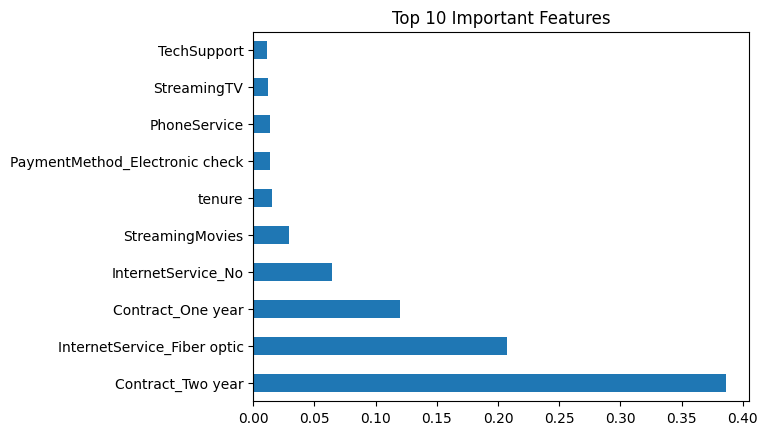

In [64]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb_model2.feature_importances_, 
                     index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(xgb_model2, f)

print("Model saved!")

Model saved!


: 